# Game conditions

## Objective

In this textbook I want to explore how specific circumstances of the matches might affect goals scored.

## Libraries

In [72]:
library(tidyverse)
library(car)
library(here)
library(ggpubr)

## Data

In [73]:
Games <- readRDS(here("1.DataCleaning-R", "Data", "RDS", "FullTeamGames.rds"))
Weather <- readRDS(here("1.DataCleaning-R", "Data", "RDS", "Weather.rds"))
DistancebetweenStadiums <- readRDS(here("1.DataCleaning-R", "Data", "RDS", "DistanceTravelled.rds"))
ELO <- readRDS(here("1.DataCleaning-R", "Data", "RDS", "ELOSScores.rds"))

In [74]:

ELOByTournament <- ELO %>%
    pivot_longer(
        cols = starts_with("WC_"),
        names_to = "tournament_year",
        values_to = "elo"
    ) %>%
    mutate(tournament_id = str_replace(tournament_year, "_", "-")) %>%
    select(team, tournament_id, team_ELO = elo)

OpponentELOByTournament <- ELOByTournament %>%
    rename(opponent_name = team, opponent_ELO = team_ELO)

Games <- Games %>%
    rename(team = team_name) %>%
    left_join(ELOByTournament, by = c("team", "tournament_id")) %>%
    left_join(OpponentELOByTournament, by = c("opponent_name", "tournament_id"))

## Rest

Lets asses how rest might help us explain variability.

`geom_smooth()` using formula = 'y ~ x'


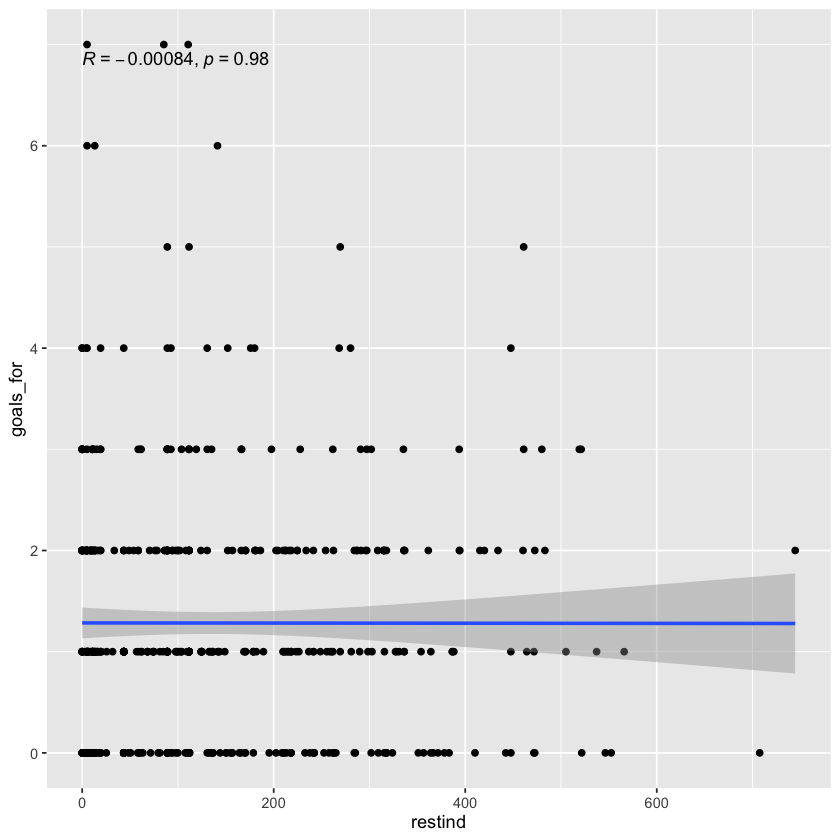

In [75]:
Games <- left_join(Games, DistancebetweenStadiums, by= c("match_id", "team_id"))

Games %>% 
    mutate(restind= (distance_traveled_km/rest_days)) %>%
        ggplot(aes(x=restind, y=goals_for)) +
             geom_point() +
                geom_smooth(method="lm", se = TRUE) +
                      stat_cor()

In [76]:
colnames(Games)

[1] "match_id"             "tournament_id"        "stage_name"          
 [4] "group_stage"          "goals_against"        "goals_for"           
 [7] "team_id"              "opponent_id"          "city_name"           
[10] "team"                 "opponent_name"        "match_date"          
[13] "match_time"           "last_game_date"       "rest_days"           
[16] "team_ELO"             "opponent_ELO"         "distance_traveled_km"

Looks exteremly weak as an indicator, lets fit spearate models.

In [77]:
m1 <- glm(goals_for ~ I(team_ELO-opponent_ELO), family=poisson, Games)
m2 <- glm(goals_for ~ I(team_ELO-opponent_ELO) + distance_traveled_km, family=poisson, Games)
m3 <- glm(goals_for ~ I(team_ELO-opponent_ELO) + rest_days, family=poisson, Games)
m4 <- glm(goals_for ~ I(team_ELO-opponent_ELO) + distance_traveled_km + rest_days, family=poisson, Games)
m5 <- glm(goals_for ~ I(team_ELO-opponent_ELO) + I(distance_traveled_km /rest_days), family=poisson, Games)

BIC(m1)
BIC(m2)
BIC(m3)
BIC(m4)
BIC(m5)

[1] 1479.812

[1] 1486.041

[1] 1485.274

[1] 1491.504

[1] 1486.035

The explannatory powere seems very limited and doesn't justify adding the variable.

### Weather

In [78]:
Weather <- left_join(Games, Weather, by ="match_id")

Warning message in left_join(Games, Weather, by = "match_id"):
"Detected an unexpected many-to-many relationship between `x` and `y`.
i Row 1 of `x` matches multiple rows in `y`.
i Row 15 of `y` matches multiple rows in `x`.
i If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning."


In [79]:
Weather <- Weather %>%
    select(match_id,temperature_2m ,wind_speed_10m, precipitation )

Games <- left_join(Games, Weather, by = "match_id")

Warning message in left_join(Games, Weather, by = "match_id"):
"Detected an unexpected many-to-many relationship between `x` and `y`.
i Row 1 of `x` matches multiple rows in `y`.
i Row 29 of `y` matches multiple rows in `x`.
i If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning."


In [80]:
glm(goals_for ~ temperature_2m, family=poisson, Games)


Call:  glm(formula = goals_for ~ temperature_2m, family = poisson, data = Games)

Coefficients:
   (Intercept)  temperature_2m  
      0.132080        0.005393  

Degrees of Freedom: 2047 Total (i.e. Null);  2046 Residual
Null Deviance:	    2644 
Residual Deviance: 2641 	AIC: 6117

In [81]:
glm(goals_for ~ precipitation, family=poisson, Games)


Call:  glm(formula = goals_for ~ precipitation, family = poisson, data = Games)

Coefficients:
  (Intercept)  precipitation  
       0.2432         0.1762  

Degrees of Freedom: 2047 Total (i.e. Null);  2046 Residual
Null Deviance:	    2644 
Residual Deviance: 2641 	AIC: 6118

In [82]:
glm(goals_for ~ wind_speed_10m, family=poisson, Games)


Call:  glm(formula = goals_for ~ wind_speed_10m, family = poisson, data = Games)

Coefficients:
   (Intercept)  wind_speed_10m  
      0.312553       -0.005771  

Degrees of Freedom: 2047 Total (i.e. Null);  2046 Residual
Null Deviance:	    2644 
Residual Deviance: 2640 	AIC: 6117

In [83]:
m1 <- glm(goals_for ~ wind_speed_10m + temperature_2m+ precipitation + (team_ELO-opponent_ELO), family=poisson, Games)
m2 <- glm(goals_for ~(team_ELO-opponent_ELO), family=poisson, Games)

BIC(m1)
BIC(m2)

[1] 5995.629

[1] 5983.408

### Managers

In [84]:
managerwchist <- readRDS(here("1.DataCleaning-R", "Data", "RDS", "ManagerWC_history.rds"))

Games <- left_join(Games,managerwchist, by = c("tournament_id", "team_id")) %>%
    mutate(
        wcgames_coached = prior_wc_matches_coached,
        r16 = prior_wc_round_of_16_matches_coached,
        wcs_coached = prior_world_cups_coached
    )

colnames(Games)

[1] "match_id"                             
 [2] "tournament_id"                        
 [3] "stage_name"                           
 [4] "group_stage"                          
 [5] "goals_against"                        
 [6] "goals_for"                            
 [7] "team_id"                              
 [8] "opponent_id"                          
 [9] "city_name"                            
[10] "team"                                 
[11] "opponent_name"                        
[12] "match_date"                           
[13] "match_time"                           
[14] "last_game_date"                       
[15] "rest_days"                            
[16] "team_ELO"                             
[17] "opponent_ELO"                         
[18] "distance_traveled_km"                 
[19] "temperature_2m"                       
[20] "wind_speed_10m"                       
[21] "precipitation"                        
[22] "team_name"                            
[23] "team_code"                            
[24] "manager_id"                           
[25] "coach_name_nft"                       
[26] "coach_url_nft"                        
[27] "pre_wc_team_matches_coached"          
[28] "coach_team_matches_source"            
[29] "coach_team_matches_cutoff_date"       
[30] "prior_wc_matches_coached"             
[31] "prior_wc_group_matches_coached"       
[32] "prior_wc_round_of_16_matches_coached" 
[33] "prior_wc_quarterfinal_matches_coached"
[34] "prior_wc_semifinal_matches_coached"   
[35] "prior_wc_third_place_matches_coached" 
[36] "prior_wc_final_matches_coached"       
[37] "prior_world_cups_coached"             
[38] "wcgames_coached"                      
[39] "r16"                                  
[40] "wcs_coached"

In [85]:
gamescoached_goals <- glm(goals_for ~ I(team_ELO-opponent_ELO) + wcgames_coached, family=poisson, Games)
summary(gamescoached_goals)

m3 <- glm(goals_for ~ I(team_ELO-opponent_ELO) + (prior_wc_final_matches_coached), family = poisson, Games)
summary(m3)


Call:
glm(formula = goals_for ~ I(team_ELO - opponent_ELO) + wcgames_coached, 
    family = poisson, data = Games)

Coefficients:
                             Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 2.070e-01  2.362e-02   8.765   <2e-16 ***
I(team_ELO - opponent_ELO)  1.464e-03  9.537e-05  15.355   <2e-16 ***
wcgames_coached            -2.052e-03  4.824e-03  -0.425     0.67    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 2643.8  on 2047  degrees of freedom
Residual deviance: 2396.6  on 2045  degrees of freedom
AIC: 5875.2

Number of Fisher Scoring iterations: 5



Call:
glm(formula = goals_for ~ I(team_ELO - opponent_ELO) + (prior_wc_final_matches_coached), 
    family = poisson, data = Games)

Coefficients:
                                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)                     2.146e-01  2.094e-02  10.245   <2e-16 ***
I(team_ELO - opponent_ELO)      1.504e-03  9.536e-05  15.771   <2e-16 ***
prior_wc_final_matches_coached -1.866e-01  7.420e-02  -2.514   0.0119 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 2643.8  on 2047  degrees of freedom
Residual deviance: 2390.2  on 2045  degrees of freedom
AIC: 5868.7

Number of Fisher Scoring iterations: 5


In [86]:
set.seed(2026)

elo_log_losses <- c()
m3_log_losses <- c()

for(i in 1:100){

    train_index <- sample(
        1:nrow(Games),
        size = 0.8 * nrow(Games)
    )

    train_data <- Games[train_index, ]
    test_data  <- Games[-train_index, ]

   
    elo_model <- glm(
        goals_for ~ I(team_ELO - opponent_ELO),
        family = poisson,
        data = train_data
    )

    
    m3 <- glm(
        goals_for ~ I(team_ELO - opponent_ELO) +
             (prior_wc_final_matches_coached),
        family = poisson,
        data = train_data
    )

    # Predictions
    elo_preds <- predict(
        elo_model,
        newdata = test_data,
        type = "response"
    )

    m3_preds <- predict(
        m3,
        newdata = test_data,
        type = "response"
    )

    
    elo_log_losses[i] <- -mean(
        dpois(
            x = test_data$goals_for,
            lambda = elo_preds,
            log = TRUE
        )
    )

    m3_log_losses[i] <- -mean(
        dpois(
            x = test_data$goals_for,
            lambda = m3_preds,
            log = TRUE
        )
    )
}

results <- data.frame(
    Model = c("ELO Only", "ELO + Coaching"),
    Mean_Log_Loss = c(
        mean(elo_log_losses),
        mean(m3_log_losses)
    ),
    SD_Log_Loss = c(
        sd(elo_log_losses),
        sd(m3_log_losses)
    )
)

results

cat(
    "\nAverage Improvement:",
    mean(elo_log_losses) - mean(m3_log_losses),
    "\n"
)

cat(
    "Percent Improvement:",
    100 * (mean(elo_log_losses) - mean(m3_log_losses)) /
    mean(elo_log_losses),
    "%\n"
)

cat(
    "Times m3 Won:",
    sum(m3_log_losses < elo_log_losses),
    "out of 100\n"
)

Model,Mean_Log_Loss,SD_Log_Loss
<chr>,<dbl>,<dbl>
ELO Only,1.432707,0.03118691
ELO + Coaching,1.431750,0.03101310



Average Improvement: 0.0009570237 
Percent Improvement: 0.06679828 %
Times m3 Won: 72 out of 100


### Tournament stage

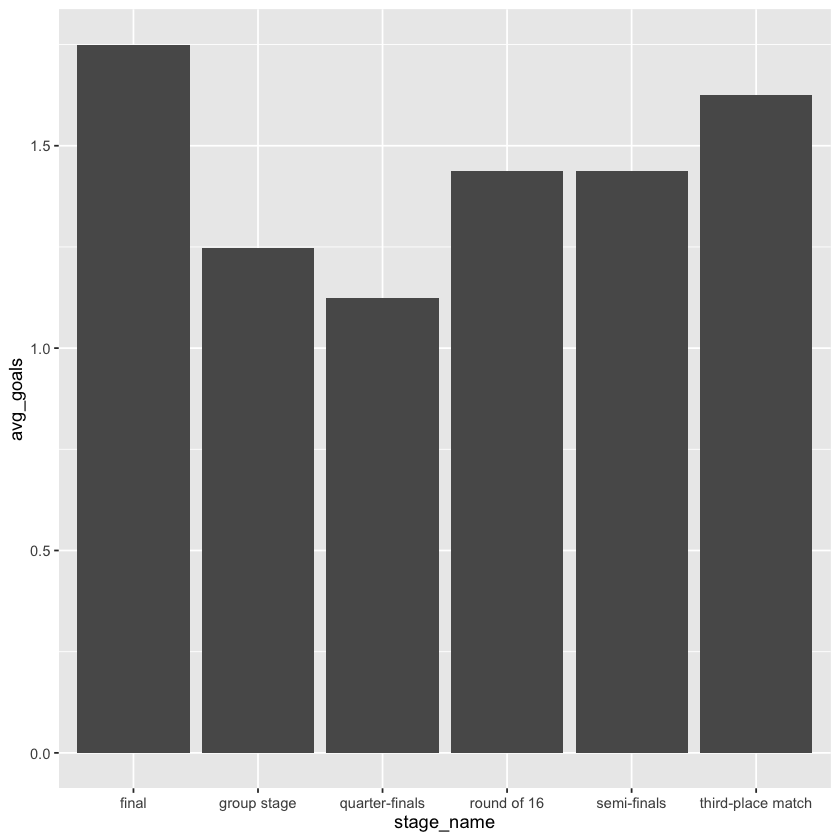

In [87]:
Games %>%
    group_by(stage_name) %>%
    summarize(avg_goals = mean(goals_for, na.rm = TRUE)) %>%
    ggplot(aes(x = stage_name, y = avg_goals)) +
    geom_col()

In [88]:
anova_model <- aov(goals_for ~ stage_name, data = Games)

summary(anova_model)

              Df Sum Sq Mean Sq F value  Pr(>F)   
stage_name     5   23.5   4.701   3.076 0.00902 **
Residuals   2042 3120.2   1.528                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

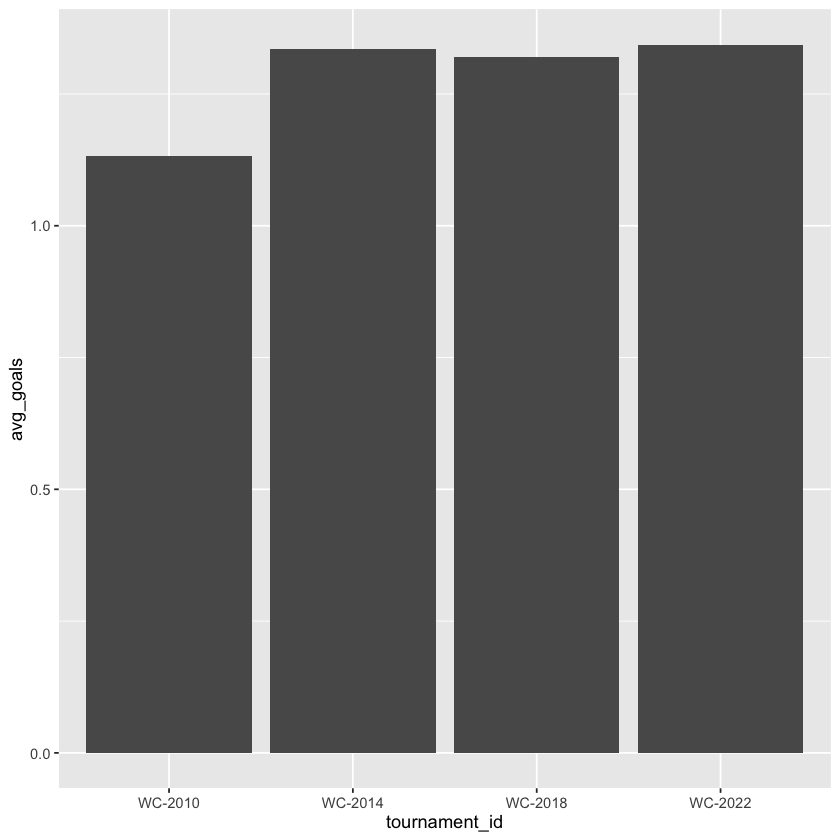

In [89]:
Games %>%
    group_by(tournament_id) %>%
    summarize(avg_goals = mean(goals_for, na.rm = TRUE)) %>%
    ggplot(aes(x = tournament_id, y = avg_goals)) +
    geom_col()

In recent years stoppage time has increased significantly, that added to changes in playing style might have affected goals. Lets try to fit the model adding a dummy variable for WC 2010 which seems o have had unusually low scores.

In [90]:
Games <- Games %>%
    mutate(SouthAfrica=ifelse(tournament_id=="WC-2010", 1, 0))

SouthAfricavar <- glm(goals_for ~ I(team_ELO-opponent_ELO) + (prior_wc_final_matches_coached) + SouthAfrica, family = poisson, Games)
summary(SouthAfricavar)


Call:
glm(formula = goals_for ~ I(team_ELO - opponent_ELO) + (prior_wc_final_matches_coached) + 
    SouthAfrica, family = poisson, data = Games)

Coefficients:
                                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)                     2.544e-01  2.341e-02  10.867  < 2e-16 ***
I(team_ELO - opponent_ELO)      1.508e-03  9.547e-05  15.795  < 2e-16 ***
prior_wc_final_matches_coached -1.941e-01  7.426e-02  -2.613 0.008967 ** 
SouthAfrica                    -1.679e-01  4.705e-02  -3.567 0.000361 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 2643.8  on 2047  degrees of freedom
Residual deviance: 2377.0  on 2044  degrees of freedom
AIC: 5857.6

Number of Fisher Scoring iterations: 5


Seems to be statistically significant. Lets check how this affects log loss.

In [91]:
set.seed(2026)

base_log_losses <- c()
m4_log_losses <- c()

for(i in 1:100){

    train_index <- sample(
        1:nrow(Games),
        size = 0.8 * nrow(Games)
    )

    train_data <- Games[train_index, ]
    test_data  <- Games[-train_index, ]

    base_model <- glm(
        goals_for ~ I(team_ELO - opponent_ELO) +
            prior_wc_final_matches_coached,
        family = poisson,
        data = train_data
    )

    m4 <- glm(
        goals_for ~ I(team_ELO - opponent_ELO) +
            prior_wc_final_matches_coached +
            SouthAfrica,
        family = poisson,
        data = train_data
    )

    base_preds <- predict(
        base_model,
        newdata = test_data,
        type = "response"
    )

    m4_preds <- predict(
        m4,
        newdata = test_data,
        type = "response"
    )

    base_log_losses[i] <- -mean(
        dpois(
            x = test_data$goals_for,
            lambda = base_preds,
            log = TRUE
        )
    )

    m4_log_losses[i] <- -mean(
        dpois(
            x = test_data$goals_for,
            lambda = m4_preds,
            log = TRUE
        )
    )
}

results <- data.frame(
    Model = c("ELO + Coaching", "ELO + Coaching + SouthAfrica"),
    Mean_Log_Loss = c(
        mean(base_log_losses),
        mean(m4_log_losses)
    ),
    SD_Log_Loss = c(
        sd(base_log_losses),
        sd(m4_log_losses)
    )
)

results

cat(
    "\nAverage Improvement:",
    mean(base_log_losses) - mean(m4_log_losses),
    "\n"
)

cat(
    "Percent Improvement:",
    100 * (mean(base_log_losses) - mean(m4_log_losses)) /
        mean(base_log_losses),
    "%\n"
)

cat(
    "Times m4 Won:",
    sum(m4_log_losses < base_log_losses),
    "out of 100\n"
)


Model,Mean_Log_Loss,SD_Log_Loss
<chr>,<dbl>,<dbl>
ELO + Coaching,1.431750,0.03101310
ELO + Coaching + SouthAfrica,1.429103,0.03077261



Average Improvement: 0.00264725 
Percent Improvement: 0.1848961 %
Times m4 Won: 80 out of 100


This seems to be strong evidence that there is an effect (althought small). Lets test if an interaction model would be better.

In [92]:
set.seed(2026)

base_log_losses <- c()
interaction_log_losses <- c()

for(i in 1:100){

    train_index <- sample(
        1:nrow(Games),
        size = 0.8 * nrow(Games)
    )

    train_data <- Games[train_index, ]
    test_data  <- Games[-train_index, ]

    # Base model: ELO + Coaching + South Africa
    base_model <- glm(
        goals_for ~ I(team_ELO - opponent_ELO) +
            prior_wc_final_matches_coached +
            SouthAfrica,
        family = poisson,
        data = train_data
    )

    # Interaction model: adds ELO difference x South Africa
    interaction_model <- glm(
        goals_for ~ I(team_ELO - opponent_ELO) *
            SouthAfrica +
            prior_wc_final_matches_coached,
        family = poisson,
        data = train_data
    )

    base_preds <- predict(
        base_model,
        newdata = test_data,
        type = "response"
    )

    interaction_preds <- predict(
        interaction_model,
        newdata = test_data,
        type = "response"
    )

    base_log_losses[i] <- -mean(
        dpois(
            x = test_data$goals_for,
            lambda = base_preds,
            log = TRUE
        )
    )

    interaction_log_losses[i] <- -mean(
        dpois(
            x = test_data$goals_for,
            lambda = interaction_preds,
            log = TRUE
        )
    )
}

results <- data.frame(
    Model = c(
        "ELO + Coaching + SouthAfrica",
        "ELO + Coaching + SouthAfrica + ELO Diff x SouthAfrica"
    ),
    Mean_Log_Loss = c(
        mean(base_log_losses),
        mean(interaction_log_losses)
    ),
    SD_Log_Loss = c(
        sd(base_log_losses),
        sd(interaction_log_losses)
    )
)

results

cat(
    "\nAverage Improvement:",
    mean(base_log_losses) - mean(interaction_log_losses),
    "\n"
)

cat(
    "Percent Improvement:",
    100 * (mean(base_log_losses) - mean(interaction_log_losses)) /
        mean(base_log_losses),
    "%\n"
)

cat(
    "Times Interaction Model Won:",
    sum(interaction_log_losses < base_log_losses),
    "out of 100\n"
)

Model,Mean_Log_Loss,SD_Log_Loss
<chr>,<dbl>,<dbl>
ELO + Coaching + SouthAfrica,1.429103,0.03077261
ELO + Coaching + SouthAfrica + ELO Diff x SouthAfrica,1.429601,0.03088488



Average Improvement: -0.0004983535 
Percent Improvement: -0.03487178 %
Times Interaction Model Won: 49 out of 100


The interaction doesn't seem important but the dummy itself is. Althought this does not give much explanatory value it does help with prediction. There may be a plentitude of reason for south africa having less goals even when accounting for team strenght and coaching experience. Maybe its stoppage time that has been increasing every world cup, maybe it is related to the wc being played during winter, maybe it has to do with travel. What seems clear is that there is a statstically significant pattern.

### Distance from home country

`geom_smooth()` using formula = 'y ~ x'


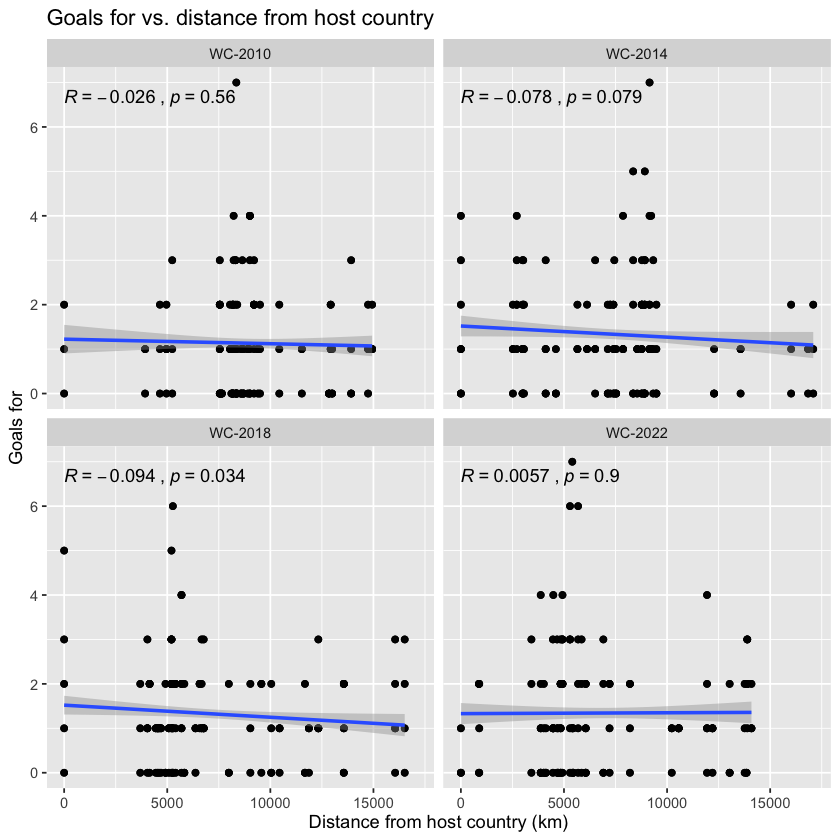

In [93]:
DistanceFromHome <- readRDS(here("1.DataCleaning-R", "Data", "RDS", "DistanceFromHome.rds"))

Games <- Games %>%
    left_join(
        DistanceFromHome %>%
            select(tournament_id, team_id, distance_from_host_km),
        by = c("tournament_id", "team_id")
    ) %>%
    filter(tournament_id != "WC-2026")

Games %>%
    ggplot(aes(x = distance_from_host_km, y = goals_for)) +
        geom_point(alpha = 0.65) +
        geom_smooth(method = "lm", se = TRUE) +
        stat_cor(aes(label = paste(after_stat(r.label), after_stat(p.label), sep = "~`,`~"))) +
        facet_wrap(~ tournament_id) +
        labs(
            x = "Distance from host country (km)",
            y = "Goals for",
            title = "Goals for vs. distance from host country"
        )

In [94]:
SouthAfricavar <- glm(goals_for ~ I(team_ELO-opponent_ELO) + (prior_wc_final_matches_coached) + SouthAfrica, family = poisson, Games)
distance <- glm(goals_for ~ I(team_ELO-opponent_ELO) + (prior_wc_final_matches_coached) + SouthAfrica + distance_from_host_km, family = poisson, Games)

BIC(SouthAfricavar)
BIC(distance)

[1] 5880.079

[1] 5869.99

In [95]:

set.seed(2026)

southafrica_log_losses <- c()
distance_log_losses <- c()

for(i in 1:100){

    train_index <- sample(
        1:nrow(Games),
        size = floor(0.8 * nrow(Games))
    )

    train <- Games[train_index, ]
    test  <- Games[-train_index, ]

    m1 <- glm(
        goals_for ~ I(team_ELO - opponent_ELO) +
            prior_wc_final_matches_coached +
            SouthAfrica,
        family = poisson,
        data = train
    )

    m2 <- glm(
        goals_for ~ I(team_ELO - opponent_ELO) +
            prior_wc_final_matches_coached +
            SouthAfrica +
            (distance_from_host_km),
        family = poisson,
        data = train
    )

    lambda1 <- predict(m1, newdata = test, type = "response")
    lambda2 <- predict(m2, newdata = test, type = "response")

    southafrica_log_losses[i] <- -mean(
        dpois(test$goals_for, lambda = lambda1, log = TRUE)
    )

    distance_log_losses[i] <- -mean(
        dpois(test$goals_for, lambda = lambda2, log = TRUE)
    )
}

comparison <- data.frame(
    Model = c(
        "ELO + Coaching + SouthAfrica",
        "ELO + Coaching + SouthAfrica + Distance"
    ),
    Mean_Log_Loss = c(
        mean(southafrica_log_losses),
        mean(distance_log_losses)
    ),
    SD_Log_Loss = c(
        sd(southafrica_log_losses),
        sd(distance_log_losses)
    )
)

comparison

avg_improvement <- mean(southafrica_log_losses) -
    mean(distance_log_losses)

percent_improvement <- 100 * avg_improvement /
    mean(southafrica_log_losses)

cat(
    "\nAverage Improvement:",
    avg_improvement,
    "\nPercent Improvement:",
    percent_improvement, "%",
    "\nTimes Distance Model Won:",
    sum(distance_log_losses < southafrica_log_losses),
    "out of 100\n"
)

Model,Mean_Log_Loss,SD_Log_Loss
<chr>,<dbl>,<dbl>
ELO + Coaching + SouthAfrica,1.429103,0.03077261
ELO + Coaching + SouthAfrica + Distance,1.425491,0.03009570



Average Improvement: 0.00361155 
Percent Improvement: 0.2527145 % 
Times Distance Model Won: 79 out of 100


This also seems substantial and relaible!

In [96]:
set.seed(2026)

linear_distance_log_losses <- c()
log_distance_log_losses <- c()

for(i in 1:100){

    train_index <- sample(
        1:nrow(Games),
        size = floor(0.8 * nrow(Games))
    )

    train <- Games[train_index, ]
    test  <- Games[-train_index, ]

    m1 <- glm(
        goals_for ~
            I(team_ELO - opponent_ELO) +
            prior_wc_final_matches_coached +
            SouthAfrica +
            distance_from_host_km,
        family = poisson,
        data = train
    )

    m2 <- glm(
        goals_for ~
            I(team_ELO - opponent_ELO) +
            prior_wc_final_matches_coached +
            SouthAfrica +
            log1p(distance_from_host_km),
        family = poisson,
        data = train
    )

    lambda1 <- predict(m1, newdata = test, type = "response")
    lambda2 <- predict(m2, newdata = test, type = "response")

    linear_distance_log_losses[i] <- -mean(
        dpois(test$goals_for, lambda1, log = TRUE)
    )

    log_distance_log_losses[i] <- -mean(
        dpois(test$goals_for, lambda2, log = TRUE)
    )
}

comparison <- data.frame(
    Model = c(
        "Linear Distance",
        "Log Distance"
    ),
    Mean_Log_Loss = c(
        mean(linear_distance_log_losses),
        mean(log_distance_log_losses)
    ),
    SD_Log_Loss = c(
        sd(linear_distance_log_losses),
        sd(log_distance_log_losses)
    )
)

comparison

avg_improvement <- mean(linear_distance_log_losses) -
    mean(log_distance_log_losses)

percent_improvement <- 100 * avg_improvement /
    mean(linear_distance_log_losses)

cat(
    "\nAverage Improvement:",
    avg_improvement,
    "\nPercent Improvement:",
    percent_improvement, "%",
    "\nTimes Log Distance Won:",
    sum(log_distance_log_losses < linear_distance_log_losses),
    "out of 100\n"
)

Model,Mean_Log_Loss,SD_Log_Loss
<chr>,<dbl>,<dbl>
Linear Distance,1.425491,0.03009570
Log Distance,1.427301,0.03049334



Average Improvement: -0.001809735 
Percent Improvement: -0.1269552 % 
Times Log Distance Won: 23 out of 100


Log distance makes the model less reliable for predictions than simple distance.